# Example: GRASP field data
Let us show how pycra-tools is used for reading field data from GRASP.
To this end, let us consider the basic example illustrated {numref}`setup`. 
The figure shows a rectangular horn antenna (brown), in the center of which there is a coordinate system with x-axis (red), y-axis (green) and z-axis (blue). 
Such antennas are used for many kinds of applications, see e.g. {cite}`Schmid_2025_wetradome` for a usage related to weather radars.
In the example presented here, we read data from near- and farfield Physical Optics simulations of the antenna radiation pattern.

In {numref}`setup`, on the one hand, the turquoise color represents a nearfield `spherical`-class grid `uv`-type coordinate system, see e.g. {cite}`ticra_tools_2024` manual p. 574, 2122, with coordinates 
$$
\label{eq:uv_coordinates}
\begin{aligned}
u&=r\sin(\theta)\cos(\varphi)\\
v&=r\sin(\theta)\sin(\varphi)
\end{aligned}
$$
with zenith angle $\theta\,$, azimuth angle $\varphi\,$, and given radius $r=1~\mathrm{m}\,$.
The three gray lines, on the other hand, represent farfield `spherical`-class cut with `polar`-type coordinate system (gray). The cuts are defined here in the "farfield" (infinitely far away from the antenna in GRASP\'s definition), but drawn at radius 1.5 m for illustration.

```{figure} setup_fields.pdf
:label: setup
:alt: Example setup for antenna pattern simulation with GRASP from TICRA. 
:align: center

Example setup for antenna pattern simulation with GRASP from TICRA.
```

On the nearfield grid we evaluated the `e_field` (electric field), and on an identical grid also the `h_field` (magnetic field); both are needed to compute the intensity for instance. 
On the farfield cuts we only simulated the electric field, from which one can calculate the antenna directivity, for example. The `linear` "polarization" definition was chosen in all cases.

## Imports and definitions for easy plotting

In [1]:
# import python libraries/modules
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# import functions from pycra-tools
from pycra_tools import readcut, readgrid, torfile

# function docstrings are available as follows:
# print(readcut.__doc__)
# print(readgrid.__doc__)
# print(torfile.__doc__)

# auxiliary function for plotting data in cuts
def cutplot_magnitudes(da):
    """
    Auxiliary function for plotting 1D field data for one frequency.

    Args:
        da (<class 'xarray.core.dataarray.DataArray'>): 
            Xarray dataframe with one frequency only

    Returns:
        fig: figure handle
        ax: axis handle
    """
    
    nr_components = len(da.comp.values)
    fig, ax = plt.subplots(1, nr_components, figsize=(4*nr_components+2, 5))
    for ii,_ in enumerate(da.comp.values):
        ax[ii].set_xlabel(f"${da.Y.attrs['texname']}$ ({da.Y.attrs['units']})" if da.Y.attrs['units'] else da.Y.attrs['texname'])
        ax[ii].set_ylabel(f"${da.comp.attrs['names_math'][ii]}$ ({da.comp.attrs['units_math'][ii]})")
        for jj,xval in enumerate(da.X.values):
            ax[ii].plot(da.Y.values, np.abs(da.values)[:,jj,ii], label=f"{xval} {da.X.units}")
        ax[ii].legend()
        ax[ii].grid(True, which='major', axis='both')
    
    return fig, ax

# auxiliary function for plotting data in grids
def gridplot_magnitudes(da):
    """
    Auxiliary function for plotting 2D field data for one frequency.

    Args:
        da (<class 'xarray.core.dataarray.DataArray'>): 
            Xarray dataframe with one frequency only

    Returns:
        fig: figure handle
        ax: axis handle
    """
    
    nr_components = len(da.comp.values)
    fig, ax = plt.subplots(1, nr_components, figsize=(4*nr_components+2, 5))
    for ii,_ in enumerate(da.comp.values):
        ax[ii].set_xlabel(f"{da.X.attrs['texname']} ({da.X.attrs['units']})" if da.X.attrs['units'] else da.X.attrs['texname'])
        ax[ii].set_ylabel(f"{da.Y.attrs['texname']} ({da.Y.attrs['units']})" if da.Y.attrs['units'] else da.Y.attrs['texname'])
        img = ax[ii].imshow(np.abs(da.values)[:,:,ii], 
                        extent=[np.min(da.X.values), np.max(da.X.values), 
                                np.min(da.Y.values), np.max(da.Y.values)], 
                        vmin=None, vmax=None, cmap=mpl.colormaps['viridis'])
        divider = make_axes_locatable(ax[ii])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(img, cax=cax)
        cax.set_ylabel(f"${da.comp.attrs['names_math'][ii]}$ ({da.comp.attrs['units_math'][ii]})")
            
    return fig, ax

## Read data from files
To fully interpreting the numerical data stored in the `.cut`/`.grd`/`.h5` files, some information is needed that is normally stored in the `.tor` file.
This information can be provided via dictionary `{userinfo}` by the user, too. On the one hand, this is useful in cases where the `.tor` file is not available.
On the other hand, sometimes the required information is not stored in the `.tor` file either. For example, when the user did not explicitely associate frequency information with the objects during the simulation, the frequency information is not stored in the `.tor` file and must be retrieved from the `.tci` file. This is not (yet) implemented in pycra-tools.

The pycra-tools package combines the information, returning an [Xarray](https://docs.xarray.dev/en/stable/) labeled multi-dimensional array, denoted *da_\** in the code below.

```{note}
Upon import into python, pycra-tools converts any frequencies to Herz: $[f]=\mathrm{Hz}\,$. Similarly, wavelengths are converted to frequencies in units of Hertz, using $f=c_0/\lambda$ with free-space speed of light $c_0=299792458$ m/s.
```

In [2]:
# define filepaths
directory_example_simulation = '/home/phjschmid/phdphysics/simulation/projects/pycra_tools/fields_example'
torfilepath = os.path.join(directory_example_simulation, 'Job_01', 'Job_01.tor')
cutfilepath = os.path.join(directory_example_simulation, 'Job_01', 'spherical_cut_far_E.cut')
grdfilepath_efield = os.path.join(directory_example_simulation, 'Job_01', 'spherical_grid_uv_near_E.grd')
grdfilepath_hfield = os.path.join(directory_example_simulation, 'Job_01', 'spherical_grid_uv_near_H.grd')

# ------------------------------------------------------------------------------
# Method 1:
# - read information from torfile into dictionary
# - use this dictionary to read the cut/grid files
# ------------------------------------------------------------------------------

tordict = torfile.tor2dict(torfilepath)
da_cut_efield = readcut(cutfilepath=cutfilepath, tordict=tordict)
da_grid_efield = readgrid(gridfilepath=grdfilepath_efield, tordict=tordict)
da_grid_hfield = readgrid(gridfilepath=grdfilepath_hfield, tordict=tordict)

# ------------------------------------------------------------------------------
# Method 2:
# - pass torfilepath for reading the cut/grid files
# Remark: reading the torfile several times, this method is slower for multiple files.
# ------------------------------------------------------------------------------

# tordict = torfile.tor2dict(torfilepath)
# da_cut_efield = readcut(cutfilepath=cutfilepath, torfilepath=torfilepath)
# da_grid_efield = readgrid(gridfilepath=grdfilepath_efield, torfilepath=torfilepath)
# da_grid_hfield = readgrid(gridfilepath=grdfilepath_hfield, torfilepath=torfilepath)

# ------------------------------------------------------------------------------
# Method 3:
# - create dictionary with necessary information (class_name, field_type)
# - use this dictionary to read the cut/grid files
# Remark for .grd-files:
#   Sometimes the frequency information is given.
#   In this case, the user-frequencies are compared with the ones in the file.
# ------------------------------------------------------------------------------

# userinfo = {
#     'class_name': 'spherical_cut',                              # (required)
#     'field_type': 'e_field',                                    # (required)
#     'coordinate_system_name': 'rectangular_horn_tx_coor_sys',   # (optional)
#     'field_region_distance_m': np.inf,                          # (optional)
#     'freqs_Hz': np.linspace(3.5,7,5)*1e9}                       # (optional)
# da_cut_efield = readcut(cutfilepath=cutfilepath, userinfo=userinfo)

# userinfo = {
#     'class_name': 'spherical_grid',                             # (required)
#     'field_type': 'e_field',                                    # (required)
#     'coordinate_system_name': 'rectangular_horn_tx_coor_sys',   # (optional)
#     'field_region_distance_m': 1,                               # (optional)
#     'freqs_Hz': np.linspace(3.5,7,5)*1e9}                       # (optional)
# da_grid_efield = readgrid(gridfilepath=grdfilepath_efield, userinfo=userinfo)

# userinfo = {
#     'class_name': 'spherical_grid',                             # (required)
#     'field_type': 'h_field',                                    # (required)
#     'coordinate_system_name': 'rectangular_horn_tx_coor_sys',   # (optional)
#     'field_region_distance_m': 1,                               # (optional)
#     'freqs_Hz': np.linspace(3.5,7,5)*1e9}                       # (optional)
# da_grid_hfield = readgrid(gridfilepath=grdfilepath_hfield, userinfo=userinfo)

## Inspect structure of the dataframes

In [8]:
print('# print(da_cut_efield)')
print(da_cut_efield)
print('\n\n# print(da_cut_efield.name)')
print(da_cut_efield.name)
print('\n\n# print(da_cut_efield.X)')
print(da_cut_efield.X)
print('\n\n# print(da_cut_efield.Y)')
print(da_cut_efield.Y)
print('\n\n# print(da_cut_efield.comp)')
print(da_cut_efield.comp)
print('\n\n# print(da_cut_efield.freq)')
print(da_cut_efield.freq)

# print(da_cut_efield)
<xarray.DataArray '/home/phjschmid/phdphysics/simulation/projects/pycra_tools/fields_example/Job_01/spherical_cut_far_E.cut' (
                                                                                                                              Y: 101,
                                                                                                                              X: 3,
                                                                                                                              comp: 2,
                                                                                                                              freq: 5)> Size: 48kB
array([[[[ 1.74484242e-15+1.45514118e-15j,
          -5.75629720e-15-1.71494957e-14j,
          -1.34395723e-16-7.33644272e-16j,
          -9.37114725e-16-5.93612733e-15j,
          -1.99469269e-15-5.57723944e-15j],
         [ 2.69564812e+00+6.56589587e+00j,
           4.02833236e+00+7.64269604e+00j,


In [7]:
print('# print(da_grid_efield)')
print(da_grid_efield)
print('\n\n# print(da_grid_efield.name)')
print(da_grid_efield.name)
print('\n\n# print(da_grid_efield.X)')
print(da_grid_efield.X)
print('\n\n# print(da_grid_efield.Y)')
print(da_grid_efield.Y)
print('\n\n# print(da_grid_efield.comp)')
print(da_grid_efield.comp)
print('\n\n# print(da_grid_efield.freq)')
print(da_grid_efield.freq)

# print(da_grid_efield)
<xarray.DataArray '/home/phjschmid/phdphysics/simulation/projects/pycra_tools/fields_example/Job_01/spherical_grid_uv_near_E.grd' (
                                                                                                                                   Y: 31,
                                                                                                                                   X: 61,
                                                                                                                                   comp: 3,
                                                                                                                                   freq: 5)> Size: 454kB
array([[[[ 5.15861528e-05-4.46895748e-05j,
           2.80121366e-05-4.58763053e-06j,
           1.97908968e-05-1.28813911e-05j,
           2.01978300e-05-1.41671314e-06j,
           9.43783472e-06-7.26531742e-07j],
         [-4.03735515e-04+1.56113416e-03j,
          -3.250

## Visualize data

Below we plot the magnitudes of the simulated electric field. 
Notice that normally the electric field has units V/m (SI-unis).
For computational reasons, GRASP renormalizes the fields to the units s.t. $[E] = \mathrm{W}^{0.5}$ (see e.g. {cite}`ticra_tools_2024` manual p. 349--350, 3275).

### Data in farfield cuts
Far enough from the antenna, there are two non-trivial field components only. Any radial contribution diminishes. The figure below shows the magnitude of the co- and cross-polarized components of the electric field. 
The zenith angle $\theta$ and the azimuth angle $\varphi$ are illustrated in {numref}`setup`.
Notice that the rectangular horns are polarized along the shorter axis, which in our case is the y-axis in {numref}`setup`, and therefore the cross-polar magnitudes (the ones parallel to the y-axis) are higher than the co-polar magnitudes (the ones parallel to the x-axis) given our choice of the coordinate system.

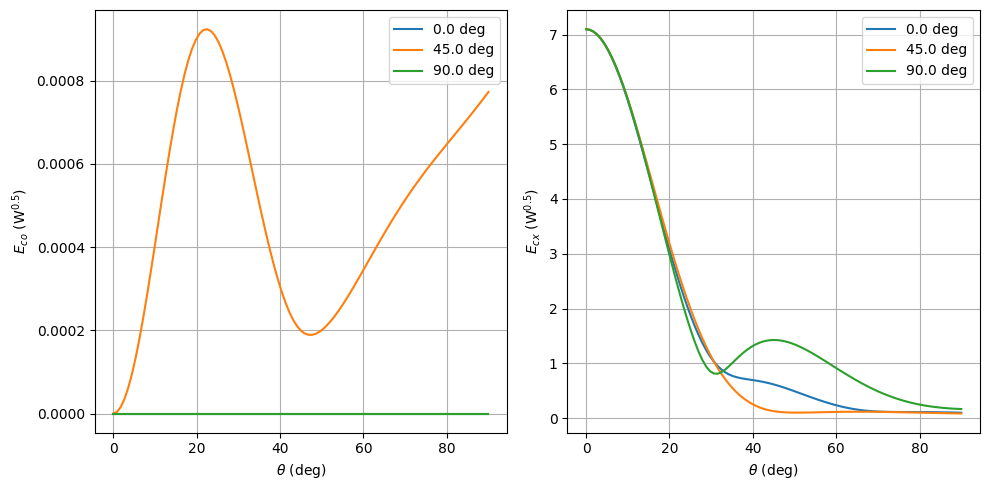

In [5]:
fig, ax = cutplot_magnitudes(da_cut_efield.sel(freq=da_cut_efield.freq.values[0]))
plt.tight_layout()
plt.show()

### Data in nearfield grids
In the nearfield, generally there are three non-trivial field components. Recall the definition of the coordinates $u=\sin(\theta)\cos(\varphi)$ and $v=\sin(\theta)\sin(\varphi)$ according to [Eq. %s](#eq:uv_coordinates) and {numref}`setup`.

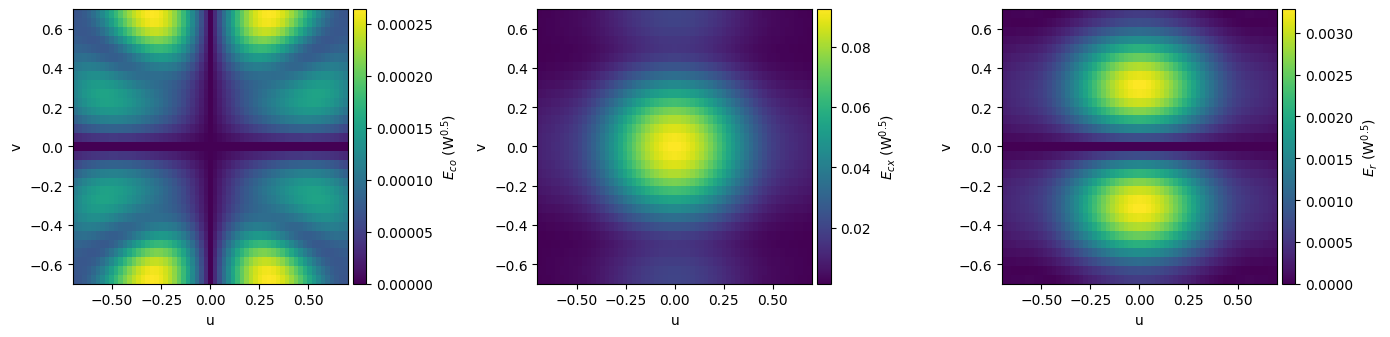

In [6]:
fig, ax = gridplot_magnitudes(da_grid_efield.sel(freq=da_grid_efield.freq.values[0]))
plt.tight_layout()
plt.show()

```{bibliography}
```